# Missing-Strut Dataset Exploration

This notebook is a safe starting point for learning how the registered JSON graph, CT TIFF volume, and STL designs are structured.

## Goals

1. Inventory the dataset without loading the full CT volume into memory.
2. Inspect junctions, struts, and unit cells in the registered JSON.
3. Read TIFF metadata and individual slices.
4. Inspect STL triangle counts and coordinate bounds.
5. Check whether the registered graph lies inside the CT voxel coordinates.
6. Define small tests that can later become MCP tools or subagent checks.

> Run the cells from top to bottom. The notebook assumes it is opened from the repository root.

In [9]:
%pip install pandas

from pathlib import Path
import json
import struct

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np
import pandas as pd
from scipy.linalg import polar
from scipy.ndimage import map_coordinates
from scipy.spatial.transform import Rotation
import tifffile

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "missing_struts"
TIFF_PATH = DATA_DIR / "tif_stacks" / "210127_Brian_Tran_strut_lattices_0point5dash1 1 Slices.tif"
REGISTERED_JSON_PATH = DATA_DIR / "registered_jsons" / "210127_Brian_Tran_strut_lattices_0point5dash1 1 Slices.json"
NOMINAL_JSON_PATH = DATA_DIR / "octet_truss_9x9x9.json"
STL_DIR = DATA_DIR / "stls"

required_paths = [DATA_DIR, TIFF_PATH, REGISTERED_JSON_PATH, NOMINAL_JSON_PATH, STL_DIR]
for path in required_paths:
    assert path.exists(), f"Missing required path: {path}"

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset:      {DATA_DIR}")

  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/68/56/fbe81c09195924d8b7b8d4461a20458fe80a6a5ed6b24f0314da684277e1/pandas-3.0.5-cp312-cp312-macosx_11_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 37.4 MB/s eta 0:00:0000:010:01

[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Project root: /Users/anthonyching/Desktop/DSC Team Project/llnl_data_science_challenge_2026
Dataset:      /Users/anthonyching/Desktop/DSC Team Project/llnl_data_science_challenge_2026/data/missing_struts


## 1. File inventory

Start by learning what is present and how large it is. This does not read file contents.

In [10]:
inventory = []
for path in sorted(DATA_DIR.rglob("*")):
    if path.is_file():
        inventory.append({
            "relative_path": str(path.relative_to(DATA_DIR)),
            "suffix": path.suffix.lower(),
            "size_mb": path.stat().st_size / (1024 ** 2),
        })

inventory_df = pd.DataFrame(inventory)
display(inventory_df)

,relative_path,suffix,size_mb
0,.DS_Store,,0.007816
1,file_names.txt,.txt,0.001640
2,octet_truss_9x9x9.json,.json,3.756310
3,registered_jsons/210127_Brian_Tran_strut_latti...,.json,4.728958
4,stls/0.1.stl,.stl,167.439445
5,stls/0.5.stl,.stl,166.828999
6,stls/0.stl,.stl,167.591270
7,stls/1.stl,.stl,166.052326
8,tif_stacks/210127_Brian_Tran_strut_lattices_0p...,.tif,990.327186


## 2. Registered and nominal JSON graphs

The JSON files contain three main collections:

- `junctions`: graph nodes with IDs and 3D positions
- `struts`: graph edges connecting two junction IDs
- `unit_cells`: groups of strut IDs belonging to each lattice cell

The registered graph uses CT-aligned coordinates. The nominal graph uses design coordinates.

In [25]:
with REGISTERED_JSON_PATH.open() as handle:
    registered_graph = json.load(handle)

with NOMINAL_JSON_PATH.open() as handle:
    nominal_graph = json.load(handle)

junctions = registered_graph["junctions"]
struts = registered_graph["struts"]
unit_cells = registered_graph["unit_cells"]

print("Registered graph keys:", list(registered_graph))
print("Junctions:", len(junctions))
print("Struts:   ", len(struts))
print("Unit cells:", len(unit_cells))

Registered graph keys: ['junctions', 'struts', 'unit_cells']
Junctions: 10206
Struts:    18468
Unit cells: 729


In [39]:
print("Example junction:")
display(junctions[0])

print("Example strut:")
display(struts[0])

print("Example unit cell:")
display(unit_cells[0])

Example junction:


{'id': 0,
 'position': [59.33960418617423, 52.18289348673591, 26.461731958208166],
 'indices': [0.0, 0.0, 0.0]}

Example strut:


{'id': 0,
 'unit_cell_edge_idx': 1,
 'junction0': 0,
 'junction1': 9,
 'thickness': 0.1}

Example unit cell:


{'id': 0,
 'struts': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 'indices': [0, 0, 0]}

In [52]:
junction_df = pd.DataFrame({
    "junction_id": [item["id"] for item in junctions],
    "x": [item["position"][0] for item in junctions],
    "y": [item["position"][1] for item in junctions],
    "z": [item["position"][2] for item in junctions],
    "i": [item["indices"][0] for item in junctions],
    "j": [item["indices"][1] for item in junctions],
    "k": [item["indices"][2] for item in junctions],
})

strut_df = pd.DataFrame(struts).rename(columns={
    "id": "strut_id",
    "junction0": "junction_0",
    "junction1": "junction_1",
})

display(junction_df.head())
display(strut_df.head())

,junction_id,x,y,z,i,j,k
0,0,59.339604,52.182893,26.461732,0.0,0.0,0.0
1,1,138.316175,51.781302,26.527177,1.0,0.0,0.0
2,2,138.717946,130.757597,26.308688,1.0,1.0,0.0
3,3,59.741375,131.159188,26.243243,0.0,1.0,0.0
4,4,59.677042,131.378007,105.220533,0.0,1.0,1.0


,strut_id,unit_cell_edge_idx,junction_0,junction_1,thickness
0,0,1,0,9,0.1
1,1,2,1,9,0.1
2,2,3,2,9,0.1
3,3,0,3,9,0.1
4,4,13,0,10,0.1


In [53]:
registered_positions = junction_df[["x", "y", "z"]].to_numpy()
nominal_positions = np.asarray([item["position"] for item in nominal_graph["junctions"]])

coordinate_summary = pd.DataFrame({
    "registered_min": registered_positions.min(axis=0),
    "registered_max": registered_positions.max(axis=0),
    "nominal_min": nominal_positions.min(axis=0),
    "nominal_max": nominal_positions.max(axis=0),
}, index=["x", "y", "z"])

display(coordinate_summary)

,registered_min,registered_max,nominal_min,nominal_max
x,58.760611,773.744679,0.0,18.0
y,48.568573,764.938918,0.0,18.0
z,24.495331,737.846341,0.0,18.0


### Registered graph projection

Plot a sample of graph edges in the XY plane. Sampling keeps the figure responsive.

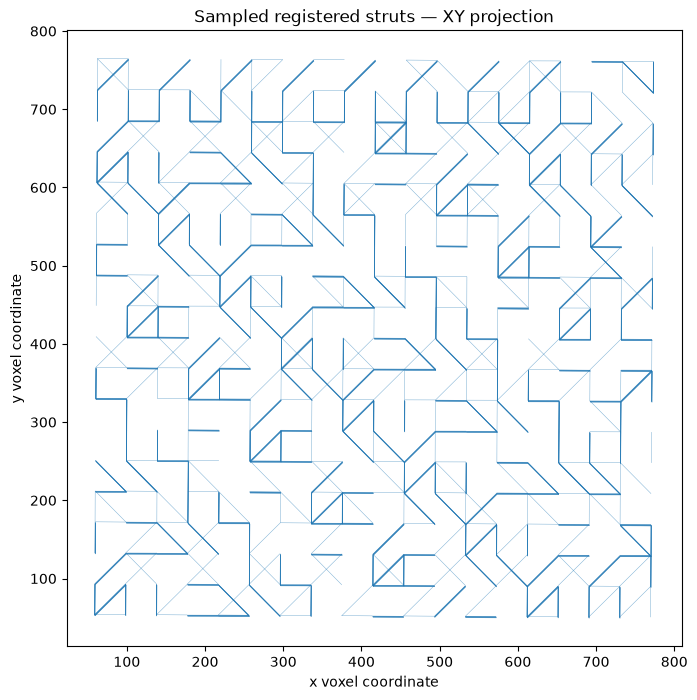

In [54]:
position_by_id = {
    item["id"]: np.asarray(item["position"], dtype=float)
    for item in junctions
}

sample_step = max(1, len(struts) // 2500)
xy_segments = []
for strut in struts[::sample_step]:
    p0 = position_by_id[strut["junction0"]]
    p1 = position_by_id[strut["junction1"]]
    xy_segments.append([p0[:2], p1[:2]])

fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(LineCollection(xy_segments, linewidths=0.35, alpha=0.6))
ax.autoscale()
ax.set_aspect("equal")
ax.set_title("Sampled registered struts — XY projection")
ax.set_xlabel("x voxel coordinate")
ax.set_ylabel("y voxel coordinate")
plt.show()

## 3. TIFF volume

Use `tifffile.TiffFile` to inspect metadata and load only the requested page. Avoid `tifffile.imread(TIFF_PATH)` during exploration because it loads the entire volume.

In [55]:
with tifffile.TiffFile(TIFF_PATH) as tif:
    ct_series = tif.series[0]
    ct_shape = ct_series.shape
    ct_dtype = ct_series.dtype
    ct_axes = ct_series.axes
    page_count = len(tif.pages)
    description = tif.pages[0].description

print("Shape:", ct_shape)
print("Dtype:", ct_dtype)
print("Axes: ", ct_axes)
print("Pages:", page_count)
print("Description:", description)

Shape: (761, 815, 837)
Dtype: uint16
Axes:  ZYX
Pages: 761
Description: ImageJ=1.54g
images=761
slices=761
loop=false
min=0.0
max=65535.0


In [56]:
SLICE_INDEX = 380

with tifffile.TiffFile(TIFF_PATH) as tif:
    ct_slice = tif.pages[SLICE_INDEX].asarray()

slice_stats = {
    "shape": ct_slice.shape,
    "dtype": str(ct_slice.dtype),
    "minimum": int(ct_slice.min()),
    "maximum": int(ct_slice.max()),
    "mean": float(ct_slice.mean()),
    "p01": float(np.percentile(ct_slice, 1)),
    "p50": float(np.percentile(ct_slice, 50)),
    "p99": float(np.percentile(ct_slice, 99)),
}
slice_stats

{'shape': (815, 837),
 'dtype': 'uint16',
 'minimum': 28949,
 'maximum': 59641,
 'mean': 33068.39734957598,
 'p01': 30474.0,
 'p50': 31977.0,
 'p99': 54449.45999999996}

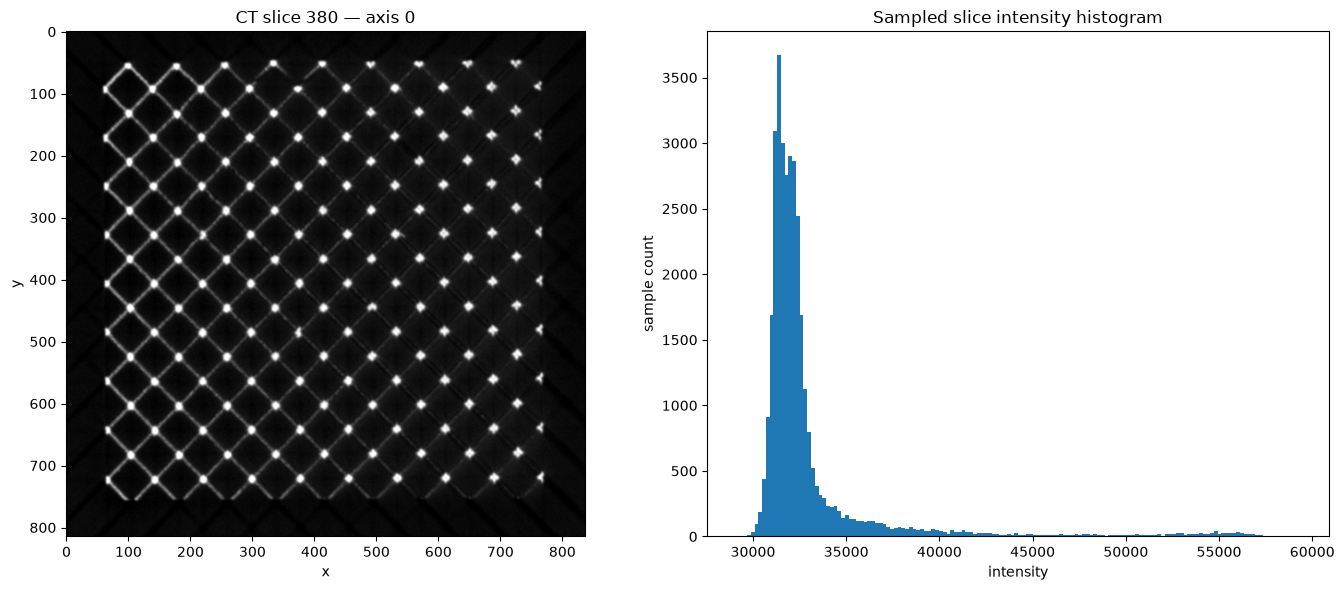

In [57]:
display_low, display_high = np.percentile(ct_slice, [1, 99.5])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(ct_slice, cmap="gray", vmin=display_low, vmax=display_high)
axes[0].set_title(f"CT slice {SLICE_INDEX} — axis 0")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

axes[1].hist(ct_slice.ravel()[::20], bins=150)
axes[1].set_title("Sampled slice intensity histogram")
axes[1].set_xlabel("intensity")
axes[1].set_ylabel("sample count")
plt.tight_layout()
plt.show()

### CT and registered-graph overlay

The registered positions appear to follow `(x, y, z)`, while the TIFF axes are `ZYX`. The overlay below plots graph edges whose midpoint is close to slice `z=380`. It is an initial visual check, not a complete registration validation.

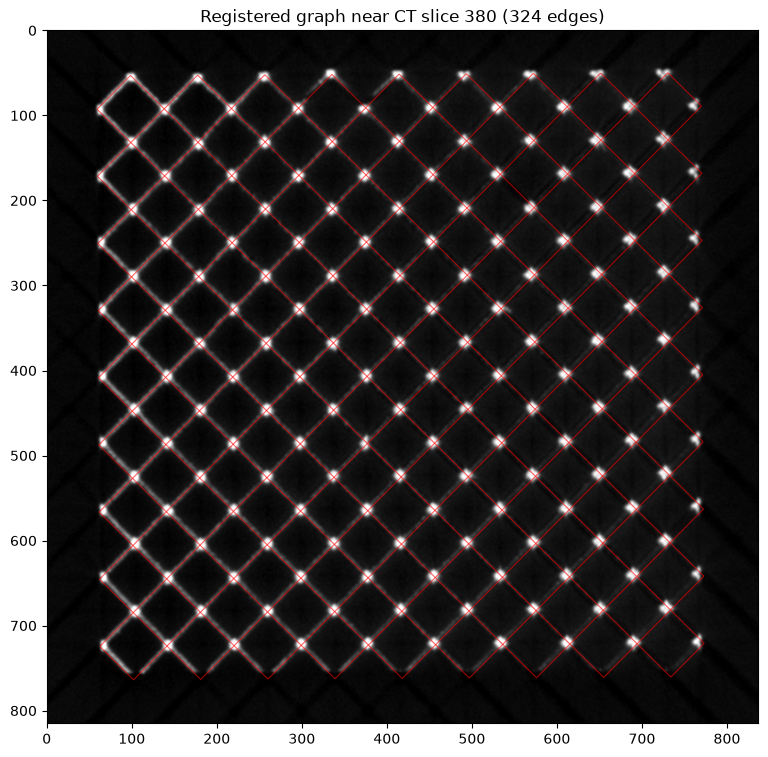

In [58]:
z_tolerance = 6
nearby_segments = []
for strut in struts:
    p0 = position_by_id[strut["junction0"]]
    p1 = position_by_id[strut["junction1"]]
    midpoint_z = (p0[2] + p1[2]) / 2
    if abs(midpoint_z - SLICE_INDEX) <= z_tolerance:
        nearby_segments.append([p0[:2], p1[:2]])

fig, ax = plt.subplots(figsize=(10, 9))
ax.imshow(ct_slice, cmap="gray", vmin=display_low, vmax=display_high)
ax.add_collection(LineCollection(nearby_segments, colors="red", linewidths=0.8, alpha=0.6))
ax.set_title(f"Registered graph near CT slice {SLICE_INDEX} ({len(nearby_segments)} edges)")
ax.set_xlim(0, ct_slice.shape[1])
ax.set_ylim(ct_slice.shape[0], 0)
plt.show()

## 4. STL designs

The helper below reads binary or ASCII STL files using NumPy and the Python standard library. The STL coordinates are not registered to the TIFF coordinates.

In [59]:
def read_stl_triangles(path: Path) -> np.ndarray:
    """Return STL triangle vertices with shape (triangle_count, 3, 3)."""
    file_size = path.stat().st_size
    with path.open("rb") as handle:
        header = handle.read(80)
        count_bytes = handle.read(4)

    if len(count_bytes) == 4:
        triangle_count = struct.unpack("<I", count_bytes)[0]
        expected_size = 84 + triangle_count * 50
        if expected_size == file_size:
            record_dtype = np.dtype([
                ("normal", "<f4", (3,)),
                ("vertices", "<f4", (3, 3)),
                ("attribute", "<u2"),
            ])
            records = np.fromfile(path, dtype=record_dtype, count=triangle_count, offset=84)
            return records["vertices"].astype(float)

    vertices = []
    with path.open("r", errors="ignore") as handle:
        for line in handle:
            fields = line.strip().split()
            if len(fields) == 4 and fields[0].lower() == "vertex":
                vertices.append([float(value) for value in fields[1:]])

    vertices = np.asarray(vertices, dtype=float)
    if len(vertices) == 0 or len(vertices) % 3 != 0:
        raise ValueError(f"Could not parse STL triangles from {path}")
    return vertices.reshape(-1, 3, 3)


In [60]:
stl_rows = []
stl_triangles = {}

for stl_path in sorted(STL_DIR.glob("*.stl")):
    triangles = read_stl_triangles(stl_path)
    stl_triangles[stl_path.name] = triangles
    points = triangles.reshape(-1, 3)
    stl_rows.append({
        "file": stl_path.name,
        "triangles": len(triangles),
        "x_min": points[:, 0].min(),
        "x_max": points[:, 0].max(),
        "y_min": points[:, 1].min(),
        "y_max": points[:, 1].max(),
        "z_min": points[:, 2].min(),
        "z_max": points[:, 2].max(),
    })

stl_summary_df = pd.DataFrame(stl_rows)
display(stl_summary_df)

,file,triangles,x_min,x_max,y_min,y_max,z_min,z_max
0,0.1.stl,3511458,-20.743635,20.749142,-25.520002,25.520002,-20.748846,20.746773
1,0.5.stl,3498656,-20.743635,20.749142,-25.520002,25.520002,-20.748846,20.746773
2,0.stl,3514642,-20.743635,20.749142,-25.520002,25.520002,-20.748846,20.746773
3,1.stl,3482368,-20.743635,20.749142,-25.520002,25.520002,-20.748846,20.746773


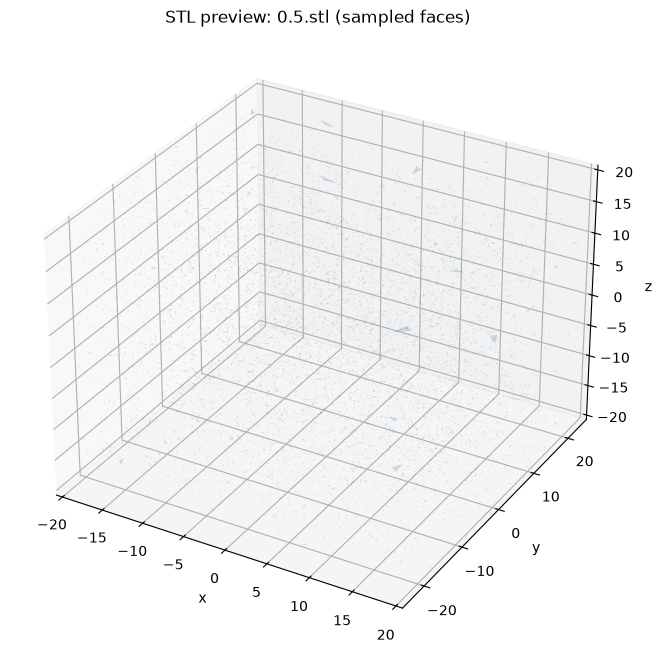

In [61]:
selected_stl = "0.5.stl"
triangles = stl_triangles[selected_stl]
display_step = max(1, len(triangles) // 12000)
display_triangles = triangles[::display_step]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
mesh = Poly3DCollection(display_triangles, alpha=0.25, linewidths=0.05)
mesh.set_facecolor("steelblue")
ax.add_collection3d(mesh)
points = triangles.reshape(-1, 3)
ax.set_xlim(points[:, 0].min(), points[:, 0].max())
ax.set_ylim(points[:, 1].min(), points[:, 1].max())
ax.set_zlim(points[:, 2].min(), points[:, 2].max())
ax.set_title(f"STL preview: {selected_stl} (sampled faces)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.show()

## 5. Measure and correct the lattice-axis tilt

The nominal and registered graphs have matching junction IDs. We can therefore fit one 3D similarity transform using all 10,206 junctions. Polar decomposition separates rigid rotation from scale and shear.

The original TIFF remains unchanged. Quantitative analysis uses the native CT coordinates for sampling and converts positions or direction vectors into the untilted lattice frame for reporting.

In [ ]:
def _junction_positions_by_id(graph):
    return {
        int(item["id"]): np.asarray(item["position"], dtype=float)
        for item in graph["junctions"]
    }


def nominal_to_ct(points_xyz, transform):
    """Map nominal lattice XYZ coordinates into native CT XYZ voxel coordinates."""
    points = np.asarray(points_xyz, dtype=float)
    original_shape = points.shape
    flat = points.reshape(-1, 3)
    mapped = (
        transform["scale"] * (transform["rotation"] @ flat.T).T
        + transform["translation"]
    )
    return mapped.reshape(original_shape)


def ct_to_nominal(points_xyz, transform):
    """Map native CT XYZ voxel coordinates into the untilted nominal frame."""
    points = np.asarray(points_xyz, dtype=float)
    original_shape = points.shape
    flat = points.reshape(-1, 3)
    centered = flat - transform["translation"]
    mapped = (transform["rotation"].T @ centered.T).T / transform["scale"]
    return mapped.reshape(original_shape)


def rotate_directions_to_lattice(vectors_xyz, transform):
    """Rotate CT-frame direction vectors into the untilted lattice frame."""
    vectors = np.asarray(vectors_xyz, dtype=float)
    original_shape = vectors.shape
    flat = vectors.reshape(-1, 3)
    mapped = (transform["rotation"].T @ flat.T).T
    return mapped.reshape(original_shape)


def fit_lattice_transform(nominal_graph, registered_graph):
    """Fit nominal-to-CT translation, uniform scale, rotation, and diagnostics."""
    nominal_by_id = _junction_positions_by_id(nominal_graph)
    registered_by_id = _junction_positions_by_id(registered_graph)
    nominal_ids = set(nominal_by_id)
    registered_ids = set(registered_by_id)
    if nominal_ids != registered_ids:
        raise ValueError(
            "Nominal and registered junction IDs differ: "
            f"nominal-only={len(nominal_ids - registered_ids)}, "
            f"registered-only={len(registered_ids - nominal_ids)}"
        )

    junction_ids = np.asarray(sorted(nominal_ids), dtype=int)
    nominal = np.asarray([nominal_by_id[item] for item in junction_ids])
    registered = np.asarray([registered_by_id[item] for item in junction_ids])

    design = np.column_stack([nominal, np.ones(len(nominal))])
    coefficients, *_ = np.linalg.lstsq(design, registered, rcond=None)
    row_linear = coefficients[:3, :]
    translation = coefficients[3, :]

    # Convert the row-vector fit into the column-vector convention p_ct = F @ p_nominal + t.
    deformation = row_linear.T
    rotation_matrix, stretch = polar(deformation)
    if np.linalg.det(rotation_matrix) < 0:
        raise ValueError("Fitted transform contains a reflection")

    scale = float(np.trace(stretch) / 3.0)
    shear_matrix = stretch - np.eye(3) * scale
    rotation = Rotation.from_matrix(rotation_matrix)
    rotation_vector = rotation.as_rotvec()
    angle_radians = float(np.linalg.norm(rotation_vector))
    axis = rotation_vector / angle_radians if angle_radians else np.array([1.0, 0.0, 0.0])

    predicted = (deformation @ nominal.T).T + translation
    residuals = registered - predicted

    return {
        "rotation": rotation_matrix,
        "translation": translation,
        "scale": scale,
        "stretch": stretch,
        "shear_matrix": shear_matrix,
        "shear_max_abs": float(np.max(np.abs(shear_matrix))),
        "euler_xyz_degrees": rotation.as_euler("xyz", degrees=True),
        "axis": axis,
        "angle_degrees": float(np.degrees(angle_radians)),
        "junction_ids": junction_ids,
        "nominal_points": nominal,
        "registered_points": registered,
        "predicted_registered_points": predicted,
        "residuals": residuals,
        "rmse_xyz": np.sqrt(np.mean(residuals ** 2, axis=0)),
        "rmse_overall": float(np.sqrt(np.mean(residuals ** 2))),
        "max_abs_residual": float(np.max(np.abs(residuals))),
    }


In [ ]:
lattice_transform = fit_lattice_transform(nominal_graph, registered_graph)

rotation_matrix = lattice_transform["rotation"]
axis_slopes_percent = []
for nominal_axis in range(3):
    primary = abs(rotation_matrix[nominal_axis, nominal_axis])
    axis_slopes_percent.extend(
        100 * abs(rotation_matrix[other_axis, nominal_axis]) / primary
        for other_axis in range(3)
        if other_axis != nominal_axis
    )

tilt_summary = pd.Series({
    "matched junctions": len(lattice_transform["junction_ids"]),
    "rotation X (degrees)": lattice_transform["euler_xyz_degrees"][0],
    "rotation Y (degrees)": lattice_transform["euler_xyz_degrees"][1],
    "rotation Z (degrees)": lattice_transform["euler_xyz_degrees"][2],
    "combined angle (degrees)": lattice_transform["angle_degrees"],
    "uniform scale (CT voxels / nominal unit)": lattice_transform["scale"],
    "translation X": lattice_transform["translation"][0],
    "translation Y": lattice_transform["translation"][1],
    "translation Z": lattice_transform["translation"][2],
    "fit RMSE (voxels)": lattice_transform["rmse_overall"],
    "maximum absolute residual (voxels)": lattice_transform["max_abs_residual"],
    "maximum shear term": lattice_transform["shear_max_abs"],
    "largest off-axis slope (percent)": max(axis_slopes_percent),
})
display(tilt_summary.to_frame("value"))

print("Rotation matrix (nominal lattice → CT XYZ):")
display(pd.DataFrame(lattice_transform["rotation"], index=list("XYZ"), columns=list("XYZ")))
print("Axis-angle unit axis:", lattice_transform["axis"])
print("A 3% rise/run slope would equal", np.degrees(np.arctan(0.03)), "degrees")

In [ ]:
predicted_registered = nominal_to_ct(
    lattice_transform["nominal_points"], lattice_transform
)
recovered_nominal = ct_to_nominal(
    lattice_transform["registered_points"], lattice_transform
)
round_trip_registered = nominal_to_ct(recovered_nominal, lattice_transform)

assert len(lattice_transform["junction_ids"]) == 10_206
assert np.max(np.abs(predicted_registered - lattice_transform["registered_points"])) < 1e-9
assert np.max(np.abs(recovered_nominal - lattice_transform["nominal_points"])) < 1e-9
assert np.max(np.abs(round_trip_registered - lattice_transform["registered_points"])) < 1e-9
assert lattice_transform["shear_max_abs"] < 1e-10
assert np.allclose(lattice_transform["stretch"], np.eye(3) * lattice_transform["scale"], atol=1e-10)

nominal_basis = np.eye(3)
ct_basis = (lattice_transform["rotation"] @ nominal_basis.T).T
recovered_basis = rotate_directions_to_lattice(ct_basis, lattice_transform)
assert np.allclose(recovered_basis, nominal_basis, atol=1e-12)

print("Tilt-transform tests passed.")
print("Maximum junction reconstruction error:", lattice_transform["max_abs_residual"], "voxels")

In [ ]:
aligned_positions = ct_to_nominal(registered_positions, lattice_transform)
registered_by_id = _junction_positions_by_id(registered_graph)
aligned_by_id = {
    junction_id: ct_to_nominal(position, lattice_transform)
    for junction_id, position in registered_by_id.items()
}

sample_step = max(1, len(struts) // 3000)
native_xy_segments = []
aligned_xy_segments = []
for strut in struts[::sample_step]:
    p0_native = registered_by_id[strut["junction0"]]
    p1_native = registered_by_id[strut["junction1"]]
    p0_aligned = aligned_by_id[strut["junction0"]]
    p1_aligned = aligned_by_id[strut["junction1"]]
    native_xy_segments.append([p0_native[:2], p1_native[:2]])
    aligned_xy_segments.append([p0_aligned[:2], p1_aligned[:2]])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].add_collection(LineCollection(native_xy_segments, linewidths=0.4))
axes[0].autoscale()
axes[0].set_aspect("equal")
axes[0].set_title("Before: registered CT XYZ frame")
axes[0].set_xlabel("CT x")
axes[0].set_ylabel("CT y")

axes[1].add_collection(LineCollection(aligned_xy_segments, linewidths=0.4))
axes[1].autoscale()
axes[1].set_aspect("equal")
axes[1].set_title("After: untilted nominal lattice frame")
axes[1].set_xlabel("lattice x")
axes[1].set_ylabel("lattice y")
plt.tight_layout()
plt.show()

In [ ]:
dual_coordinate_rows = []
for strut in struts[:10]:
    p0_ct = registered_by_id[strut["junction0"]]
    p1_ct = registered_by_id[strut["junction1"]]
    p0_lattice = ct_to_nominal(p0_ct, lattice_transform)
    p1_lattice = ct_to_nominal(p1_ct, lattice_transform)
    direction_ct = p1_ct - p0_ct
    direction_lattice = rotate_directions_to_lattice(direction_ct, lattice_transform)
    direction_lattice /= np.linalg.norm(direction_lattice)
    dual_coordinate_rows.append({
        "strut_id": strut["id"],
        "p0_ct_xyz": p0_ct,
        "p1_ct_xyz": p1_ct,
        "p0_lattice_xyz": p0_lattice,
        "p1_lattice_xyz": p1_lattice,
        "direction_lattice_xyz": direction_lattice,
    })

dual_coordinate_df = pd.DataFrame(dual_coordinate_rows)
display(dual_coordinate_df)

### Lattice-aligned oblique plane without resampling the full TIFF

This helper creates only one requested plane. It converts nominal lattice coordinates into CT XYZ coordinates, reverses them to TIFF `ZYX` indexing, and interpolates from a read-only memory map.

In [ ]:
def sample_lattice_aligned_plane(
    ct_volume_zyx,
    transform,
    axis="z",
    coordinate=9.0,
    first_range=(0.0, 18.0),
    second_range=(0.0, 18.0),
    output_shape=(512, 512),
    interpolation_order=1,
):
    """Sample one plane defined in untilted nominal lattice coordinates."""
    axis = axis.lower()
    if axis not in {"x", "y", "z"}:
        raise ValueError("axis must be 'x', 'y', or 'z'")

    first = np.linspace(*first_range, output_shape[1])
    second = np.linspace(*second_range, output_shape[0])
    grid_first, grid_second = np.meshgrid(first, second)

    if axis == "z":
        nominal_xyz = np.stack([
            grid_first,
            grid_second,
            np.full_like(grid_first, coordinate),
        ], axis=-1)
    elif axis == "y":
        nominal_xyz = np.stack([
            grid_first,
            np.full_like(grid_first, coordinate),
            grid_second,
        ], axis=-1)
    else:
        nominal_xyz = np.stack([
            np.full_like(grid_first, coordinate),
            grid_first,
            grid_second,
        ], axis=-1)

    ct_xyz = nominal_to_ct(nominal_xyz, transform)
    sampling_coordinates_zyx = np.moveaxis(ct_xyz[..., [2, 1, 0]], -1, 0)
    return map_coordinates(
        ct_volume_zyx,
        sampling_coordinates_zyx,
        order=interpolation_order,
        mode="constant",
        cval=0,
        prefilter=interpolation_order > 1,
    )


ct_volume_read_only = tifffile.memmap(TIFF_PATH, mode="r")
assert ct_volume_read_only.shape == ct_shape
aligned_midplane = sample_lattice_aligned_plane(
    ct_volume_read_only,
    lattice_transform,
    axis="z",
    coordinate=9.0,
)

plane_low, plane_high = np.percentile(aligned_midplane, [1, 99.5])
plt.figure(figsize=(8, 8))
plt.imshow(aligned_midplane, cmap="gray", vmin=plane_low, vmax=plane_high, origin="lower")
plt.title("Untilted lattice midplane (nominal z = 9)")
plt.xlabel("nominal x")
plt.ylabel("nominal y")
plt.show()

## 6. Coordinate-system and alignment checks

The registered graph is expected to fit inside the CT voxel volume. The nominal graph and STL use different coordinates and require registration before direct overlay.

In [62]:
# TIFF axes are ZYX; graph positions are interpreted as XYZ.
z_size, y_size, x_size = ct_shape

alignment_checks = {
    "all_x_inside_ct": bool(np.all((registered_positions[:, 0] >= 0) & (registered_positions[:, 0] < x_size))),
    "all_y_inside_ct": bool(np.all((registered_positions[:, 1] >= 0) & (registered_positions[:, 1] < y_size))),
    "all_z_inside_ct": bool(np.all((registered_positions[:, 2] >= 0) & (registered_positions[:, 2] < z_size))),
    "registered_and_nominal_junction_counts_match": len(registered_graph["junctions"]) == len(nominal_graph["junctions"]),
    "registered_and_nominal_strut_counts_match": len(registered_graph["struts"]) == len(nominal_graph["struts"]),
}

alignment_checks

{'all_x_inside_ct': True,
 'all_y_inside_ct': True,
 'all_z_inside_ct': True,
 'registered_and_nominal_junction_counts_match': True,
 'registered_and_nominal_strut_counts_match': True}

## 7. Automated sanity tests

These checks are useful prototypes for future MCP tools and subagents.

In [63]:
junction_ids = [item["id"] for item in junctions]
strut_ids = [item["id"] for item in struts]
junction_id_set = set(junction_ids)
strut_id_set = set(strut_ids)

assert len(junction_ids) == len(junction_id_set), "Junction IDs are not unique"
assert len(strut_ids) == len(strut_id_set), "Strut IDs are not unique"
assert all(item["junction0"] in junction_id_set for item in struts)
assert all(item["junction1"] in junction_id_set for item in struts)
assert all(strut_id in strut_id_set for cell in unit_cells for strut_id in cell["struts"])
assert all(alignment_checks.values()), alignment_checks
assert ct_shape == (761, 815, 837)
assert ct_dtype == np.dtype("uint16") or ct_dtype == np.dtype(">u2")

print("All JSON, TIFF, and registered-coordinate sanity checks passed.")

All JSON, TIFF, and registered-coordinate sanity checks passed.


## 8. Suggested next experiments

After the cells above work, continue in this order:

1. **One-strut CT profile:** Choose one `strut_id`, interpolate points between its two registered junctions, and sample CT intensity along the path.
2. **Cylindrical sampling:** Sample a small radius around the path rather than only its centerline.
3. **Healthy versus missing evidence:** Compare occupancy and intensity profiles for several visually strong and weak struts.
4. **Diameter estimate:** Measure cross-sections away from junctions and report diameter in voxels first.
5. **Physical calibration:** Verify voxel spacing before converting voxel measurements to microns.
6. **Defect table:** Build one row per strut with occupancy, longest gap, median diameter, orientation, and boundary distance.
7. **Spatial distribution:** Test whether missing, thin, or broken struts cluster by location or orientation.

### Important cautions

- Do not treat STL coordinates as CT voxel coordinates without registration.
- Do not claim a 350 µm diameter until physical voxel spacing is verified.
- Do not load the entire TIFF unless the analysis requires it and memory use is understood.
- Keep early experiments read-only and write generated artifacts to a separate output directory.